In [1]:
#importing necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#dataset
df = pd.read_csv('nba_shooting_and_offense.csv')

In [2]:
def three_pt_efficiency_model(data):
    """
    Uses linear regression to predict the offensive rating of every NBA team based on
    the averages of the 3 pt percentage and 3 ptrs attempted per team.
    
    Parameters:
    df (pd.DataFrame): NBA df with the '3P%', '3PA', and 'ORtg' columns
    
    Returns:
    tuple: tuple with the coefficients, intercept, and r^2
    """
    #feature matrix X
    X = np.column_stack([
        np.ones(len(data)),  
        data['3P%'].values,  
        data['3PA'].values   
    ])
    
    #target variable y
    y = data['ORtg'].values
    
    #coefficients
    XTX = np.dot(X.transpose(), X)
    XTX_inv = np.linalg.inv(XTX)
    XTy = np.dot(X.transpose(), y)
    coefficients = np.dot(XTX_inv, XTy)
    
    #intercept and feature coefficients
    intercept = coefficients[0]
    three_pt_pct = coefficients[1]
    three_pt_att = coefficients[2]
    
    #predicted vals
    y_pred = np.dot(X, coefficients)
    
    #R-squared
    total = np.sum((y - np.mean(y))**2)
    residual = np.sum((y - y_pred)**2)
    r_squared = 1 - (residual / total)
    
    return {
        'intercept': intercept,
        'three_pt_pct_coefficient': three_pt_pct,
        'three_pt_attempts_coefficient': three_pt_att,
        'r_squared': r_squared,
        'predictions': y_pred
    }

results = three_pt_efficiency_model(df)

Results:
R-squared = 0.721
Predicted ORtg equation: 0.208 + 0.023*3P% + 0.002*3PA


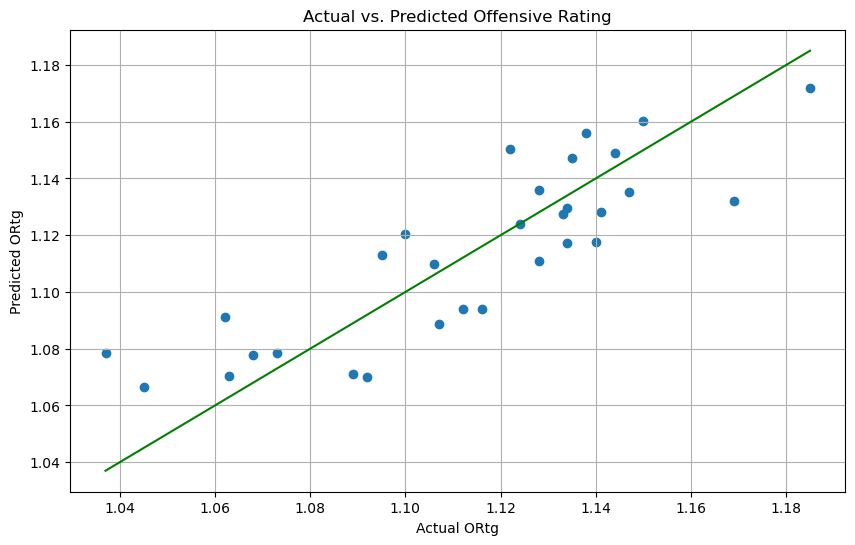

NBA Teams Overperforming Predictions:
            Team   ORtg  Predicted_ORtg  Prediction_Error
11       Indiana  1.169        1.131981          0.037019
7         Denver  1.140        1.117574          0.022426
21       Orlando  1.092        1.069945          0.022055
28          Utah  1.116        1.094149          0.021851
10       Houston  1.107        1.088735          0.018265
27       Toronto  1.089        1.071009          0.017991
4        Chicago  1.112        1.094082          0.017918
22  Philadelphia  1.128        1.110744          0.017256
0        Atlanta  1.134        1.117256          0.016744
1         Boston  1.185        1.172026          0.012974

NBA Teams Underperforming Predictions:
            Team   ORtg  Predicted_ORtg  Prediction_Error
14       Memphis  1.037        1.078569         -0.041569
3      Charlotte  1.062        1.091199         -0.029199
17     Minnesota  1.122        1.150252         -0.028252
24      Portland  1.045        1.066643         -0.0

In [4]:
#results
print("Results:")
print(f"R-squared = {results['r_squared']:.3f}")
print(f"Predicted ORtg equation: {results['intercept']:.3f} + "
     f"{results['three_pt_pct_coefficient']:.3f}*3P% + "
      f"{results['three_pt_attempts_coefficient']:.3f}*3PA")

#graph of actual vs predicted vals
plt.figure(figsize=(10, 6))
plt.scatter(df['ORtg'], results['predictions'])
plt.plot([df['ORtg'].min(), df['ORtg'].max()], 
         [df['ORtg'].min(), df['ORtg'].max()], 'g-')
plt.xlabel('Actual ORtg')
plt.ylabel('Predicted ORtg')
plt.title('Actual vs. Predicted Offensive Rating')
plt.grid(True)
plt.show()

#comparing actual vs predicted vals
df['Predicted_ORtg'] = results['predictions']
df['Prediction_Error'] = df['ORtg'] - df['Predicted_ORtg']

print("NBA Teams Overperforming Predictions:")
print(df.nlargest(10, 'Prediction_Error')[['Team', 'ORtg', 'Predicted_ORtg', 'Prediction_Error']])

print("\nNBA Teams Underperforming Predictions:")
print(df.nsmallest(10, 'Prediction_Error')[['Team', 'ORtg', 'Predicted_ORtg', 'Prediction_Error']])